In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [57]:
df=pd.read_csv('/content/social_ads_dataset_2000_rows.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15987230,Male,31,115267,0
1,15079954,Male,36,128561,1
2,15567130,Male,55,48192,0
3,15500891,Male,30,22324,0
4,15055399,Female,21,137469,0
...,...,...,...,...,...
1995,15578698,Female,34,55901,0
1996,15606720,Female,32,75923,0
1997,15536489,Female,52,142051,1
1998,15692128,Male,57,52735,0


In [58]:
x=df.drop(['User ID', 'Gender', 'Purchased'], axis=1)
y=df['Purchased']

In [59]:
x

,Age,EstimatedSalary
0,31,115267
1,36,128561
2,55,48192
3,30,22324
4,21,137469
...,...,...
1995,34,55901
1996,32,75923
1997,52,142051
1998,57,52735


In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:
ss=StandardScaler()
xs=ss.fit_transform(x)

In [62]:
xs.shape

(2000, 2)

In [15]:
!pip install -q tf-keras

In [41]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [64]:
model=Sequential()

model.add(Dense(10, activation='relu', input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [65]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(loss='binary_crossentropy', metrics=['accuracy'])

**Now doing batch Gradient Descent, taking entire training dataset at once and updating W,B only once per epochs**

**In this batch size will be no. of rows in Data**

**and due to this faster execution happening**



In [67]:
logs1=model.fit(xs, y, epochs=10, batch_size=2000, validation_split=0.2)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 968ms/step - accuracy: 0.5888 - loss: 0.6784 - val_accuracy: 0.6375 - val_loss: 0.6666
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.6225 - loss: 0.6704 - val_accuracy: 0.6725 - val_loss: 0.6608
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6500 - loss: 0.6647 - val_accuracy: 0.7000 - val_loss: 0.6559
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6950 - loss: 0.6600 - val_accuracy: 0.7450 - val_loss: 0.6516
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7369 - loss: 0.6557 - val_accuracy: 0.7850 - val_loss: 0.6476
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7738 - loss: 0.6518 - val_accuracy: 0.8100 - val_loss: 0.6439
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7937 - loss: 0.6481 - val_accuracy: 0.8200 - val_loss: 0.6404
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8062 - loss: 0.6447 - val_accuracy: 0.8275 - val_loss: 0.637

**Now Lets do stochastic Gradient Descent --- In this we are updating W,B after every Row's prediction**

**In this batch size will be 1**

**in this 288 training rows, so W,B will be updated 288 times per epochs and if 10 epochs are there, so it will be 2880 times W,B be updated and time will be increased due to this but convergence will be faster**

In [68]:
model2=Sequential()

model2.add(Dense(10, activation='relu', input_dim=2))
model2.add(Dense(10, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

In [69]:
model2.compile(loss='binary_crossentropy', metrics=['accuracy'])

In [70]:
logs2=model2.fit(xs, y, epochs=10, batch_size=1, validation_split=0.2)

Epoch 1/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8756 - loss: 0.2852 - val_accuracy: 0.9575 - val_loss: 0.1321
Epoch 2/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9550 - loss: 0.1129 - val_accuracy: 0.9625 - val_loss: 0.0953
Epoch 3/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9663 - loss: 0.0822 - val_accuracy: 0.9700 - val_loss: 0.0797
Epoch 4/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9719 - loss: 0.0645 - val_accuracy: 0.9750 - val_loss: 0.0581
Epoch 5/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9731 - loss: 0.0564 - val_accuracy: 0.9700 - val_loss: 0.0617
Epoch 6/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9787 - loss: 0.0494 - val_accuracy: 0.9800 - val_loss: 0.0447
Epoch 7/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9844 - loss: 0.0426 - val_accuracy: 0.9850 - val_loss: 0.0376
Epoch 8/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9819 - loss: 0.0405 - 

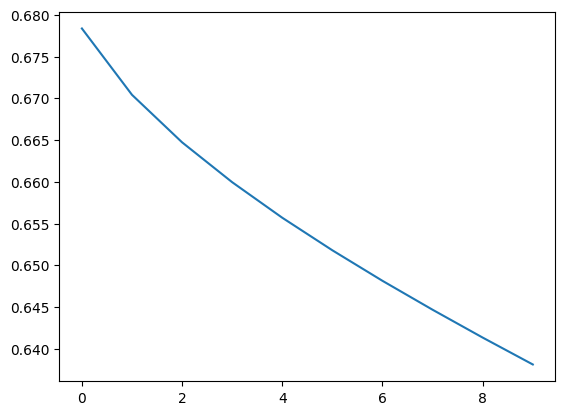

In [71]:
plt.plot(logs1.history['loss'])
# Batch

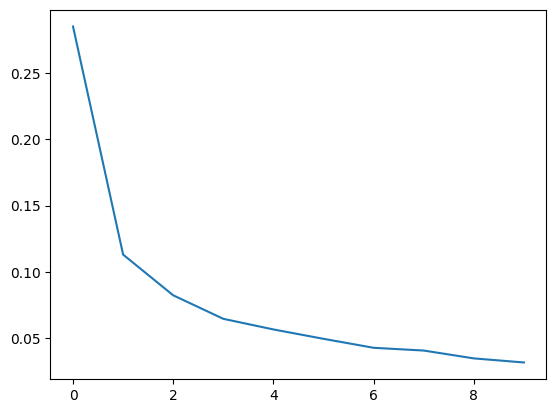

In [72]:
plt.plot(logs2.history['loss'])